In [1]:
import sys
print(sys.executable)

c:\Users\Galang\Downloads\pokemon-tcg-checker\pokemon-tcg-checker\backend\.venv\Scripts\python.exe


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.metrics import structural_similarity as ssim

DATA_DIR = Path(r"C:\Users\Galang\Downloads\pokemon-tcg-checker\pokemon-tcg-checker\backend\data")
REFERENCE_PATH = DATA_DIR / "reference" / "card-back-official.jpg"

reference_img = cv2.imread(str(REFERENCE_PATH))
reference_gray = cv2.cvtColor(reference_img, cv2.COLOR_BGR2GRAY)

print(f"Reference loaded: {reference_gray.shape}")

Reference loaded: (256, 256)


In [9]:
def align_image(sample_img, reference_gray):
    sample_gray = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(nfeatures=2000)
    kp1, des1 = orb.detectAndCompute(reference_gray, None)
    kp2, des2 = orb.detectAndCompute(sample_gray, None)

    if des1 is None or des2 is None:
        return None

    matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = matcher.match(des1, des2)
    matches = sorted(matches, key=lambda m: m.distance)

    good_matches = matches[:50]
    if len(good_matches) < 10:
        return None

    ref_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    sample_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    homography, _ = cv2.findHomography(sample_pts, ref_pts, cv2.RANSAC, 5.0)
    if homography is None:
        return None

    h, w = reference_gray.shape
    aligned = cv2.warpPerspective(sample_gray, homography, (w, h))
    return aligned

In [10]:
def compute_ssim_score(aligned_img, reference_gray):
    score, _ = ssim(aligned_img, reference_gray, full=True)
    return score

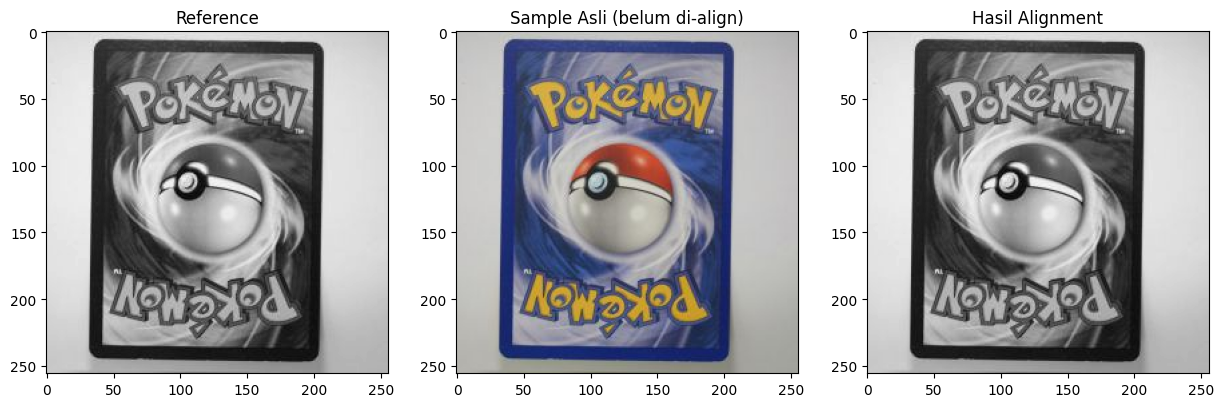

SSIM: 1.000


In [11]:
sample_path = list((DATA_DIR / "dataset" / "real").glob("*.jpg"))[0]
sample_img = cv2.imread(str(sample_path))
aligned = align_image(sample_img, reference_gray)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(reference_gray, cmap='gray')
axes[0].set_title('Reference')
axes[1].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Sample Asli (belum di-align)')
axes[2].imshow(aligned, cmap='gray')
axes[2].set_title('Hasil Alignment')
plt.show()

print(f"SSIM: {compute_ssim_score(aligned, reference_gray):.3f}")

In [12]:
def evaluate_folder(folder_path: Path, label: str):
    scores = []
    for img_path in folder_path.glob("*.jpg"):
        sample_img = cv2.imread(str(img_path))
        if sample_img is None:
            continue

        aligned = align_image(sample_img, reference_gray)
        if aligned is None:
            print(f"  [{label}] {img_path.name}: gagal align, skip")
            continue

        score = compute_ssim_score(aligned, reference_gray)
        scores.append(score)

    return scores

real_scores = evaluate_folder(DATA_DIR / "dataset" / "real", "real")
fake_scores = evaluate_folder(DATA_DIR / "dataset" / "fake", "fake")

print(f"Rata-rata SSIM real : {np.mean(real_scores):.3f}")
print(f"Rata-rata SSIM fake : {np.mean(fake_scores):.3f}")

Rata-rata SSIM real : 0.872
Rata-rata SSIM fake : 0.788


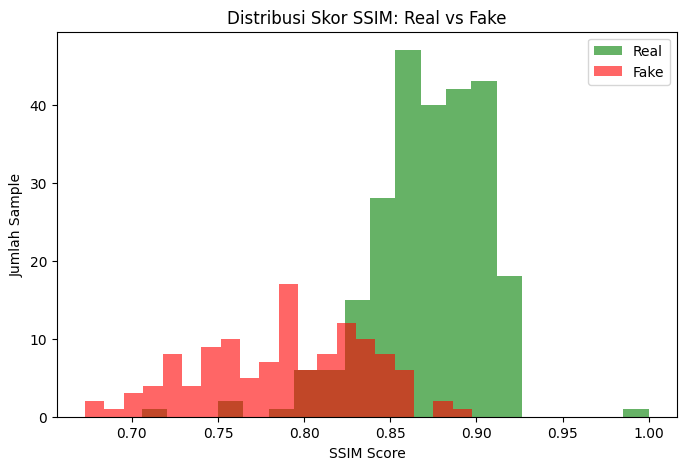

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(real_scores, bins=20, alpha=0.6, label='Real', color='green')
plt.hist(fake_scores, bins=20, alpha=0.6, label='Fake', color='red')
plt.xlabel('SSIM Score')
plt.ylabel('Jumlah Sample')
plt.legend()
plt.title('Distribusi Skor SSIM: Real vs Fake')
plt.show()